In [5]:
import pandas as pd

red_df = pd.read_csv('winequality-red.csv', sep=';', header = 0, engine = 'python')
white_df = pd.read_csv('winequality-white.csv', sep=';', header = 0, engine = 'python')

red_df.to_csv('winequality-red2.csv', index = False)
white_df.to_csv('winequality-white2.csv', index = False)

In [6]:
red_df.insert(0, column = 'type', value = 'red')
white_df.insert(0, column = 'type', value = 'white')

wine = pd.concat([red_df, white_df])
wine.to_csv('wine.csv', index = False)

독립변수 = 입력변수 = 설명변수

종속변수 = 출력변수 = 반응변수 

In [7]:
wine.columns = wine.columns.str.replace(' ', '_')

In [8]:
wine.reset_index(inplace = True)

In [9]:
print(wine.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 6497 non-null   int64  
 1   type                  6497 non-null   object 
 2   fixed_acidity         6497 non-null   float64
 3   volatile_acidity      6497 non-null   float64
 4   citric_acid           6497 non-null   float64
 5   residual_sugar        6497 non-null   float64
 6   chlorides             6497 non-null   float64
 7   free_sulfur_dioxide   6497 non-null   float64
 8   total_sulfur_dioxide  6497 non-null   float64
 9   density               6497 non-null   float64
 10  pH                    6497 non-null   float64
 11  sulphates             6497 non-null   float64
 12  alcohol               6497 non-null   float64
 13  quality               6497 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 710.7+ KB
None


In [13]:
wine.describe()

,index,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,2042.535632,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1436.926393,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,812.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,1649.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,3273.000000,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,4897.000000,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [10]:
wine.groupby('type')['quality'].mean()

type
red      5.636023
white    5.877909
Name: quality, dtype: float64

In [1]:
pip install statsmodels

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [12]:
from scipy import stats
from statsmodels.formula.api import ols, glm
red_wine_quality = wine.loc[wine['type'] == 'red', 'quality']
white_wine_quality = wine.loc[wine['type'] == 'white', 'quality']
stats.ttest_ind(red_wine_quality, white_wine_quality, equal_var = False)

Ttest_indResult(statistic=-10.149363059143164, pvalue=8.168348870049682e-24)

In [14]:
Rformula = """quality ~ fixed_acidity + volatile_acidity + citric_acid +
              residual_sugar + chlorides + free_sulfur_dioxide + total_sulfur_dioxide +
              density + pH + sulphates + alcohol"""
regression_result = ols(Rformula, data = wine).fit()
regression_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     243.3
Date:                Thu, 06 Apr 2023   Prob (F-statistic):               0.00
Time:                        03:07:27   Log-Likelihood:                -7215.5
No. Observations:                6497   AIC:                         1.445e+04
Df Residuals:                    6485   BIC:                         1.454e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               55.7627     11.894      4.688      0.000      32.447      79.079
fixed_acidity            0.0677      0.016      4.346      0.000       0.037       0.098
volatile_acidity        -1.3279      0.077    -17.162      0.000      -1.480      -1.176
citric_acid             -0.1097      0.080     -1.377      0.168      -0.266       0.046
residual_sugar           0.0436      0.005      8.449      0.000       0.033       0.054
chlorides               -0.4837      0.333     -1.454      0.146      -1.136       0.168
free_sulfur_dioxide      0.0060      0.001      7.948      0.000       0.004       0.007
total_sulfur_dioxide    -0.0025      0.000     -8.969      0.000      -0.003      -0.002
density                -54.9669     12.137     -4.529      0.000     -78.760     -31.173
pH                       0.4393      0.090      4.861      0.000       0.262       0.616
sulphates                0.7683      0.076     10.092      0.000       0.619       0.917
alcohol                  0.2670      0.017     15.963      0.000       0.234       0.300
==============================================================================
Omnibus:                      144.075   Durbin-Watson:                   1.646
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              324.712
Skew:                          -0.006   Prob(JB):                     3.09e-71
Kurtosis:                       4.095   Cond. No.                     2.49e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.49e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [15]:
sample1 = wine[wine.columns.difference(['quality', 'type'])]
sample1 = sample1[0:5][:]
sample1_predict = regression_result.predict(sample1)
sample1_predict

0    4.997607
1    4.924993
2    5.034663
3    5.680333
4    4.997607
dtype: float64

In [16]:
wine[0:5]['quality']

0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [18]:
data = [7.8, 0.58, 0.02, 2.0, 0.073, 9.0, 18.0, 0.9968, 3.36, 0.57, 9.5]
data = {"fixed_acidity" : [7.8], "volatile_acidity" : 0.58, "citric_acid" : [0.02]
        ,"residual_sugar" : 2.0, "chlorides" : 0.073, "free_sulfur_dioxide" : [9.0]
        ,"total_sulfur_dioxide" : [18.0], "density" : [0.9968], "pH" : [3.36]
        ,"sulphates" : [0.57], "alcohol" : [9.5]}
sample2 = pd.DataFrame(data, columns = sample1.columns)
sample2

,alcohol,chlorides,citric_acid,density,fixed_acidity,free_sulfur_dioxide,index,pH,residual_sugar,sulphates,total_sulfur_dioxide,volatile_acidity
0,9.5,0.073,0.02,0.9968,7.8,9.0,NaN,3.36,2.0,0.57,18.0,0.58


In [19]:
sample2_predict = regression_result.predict(sample2)
sample2_predict

0    5.238861
dtype: float64

eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1


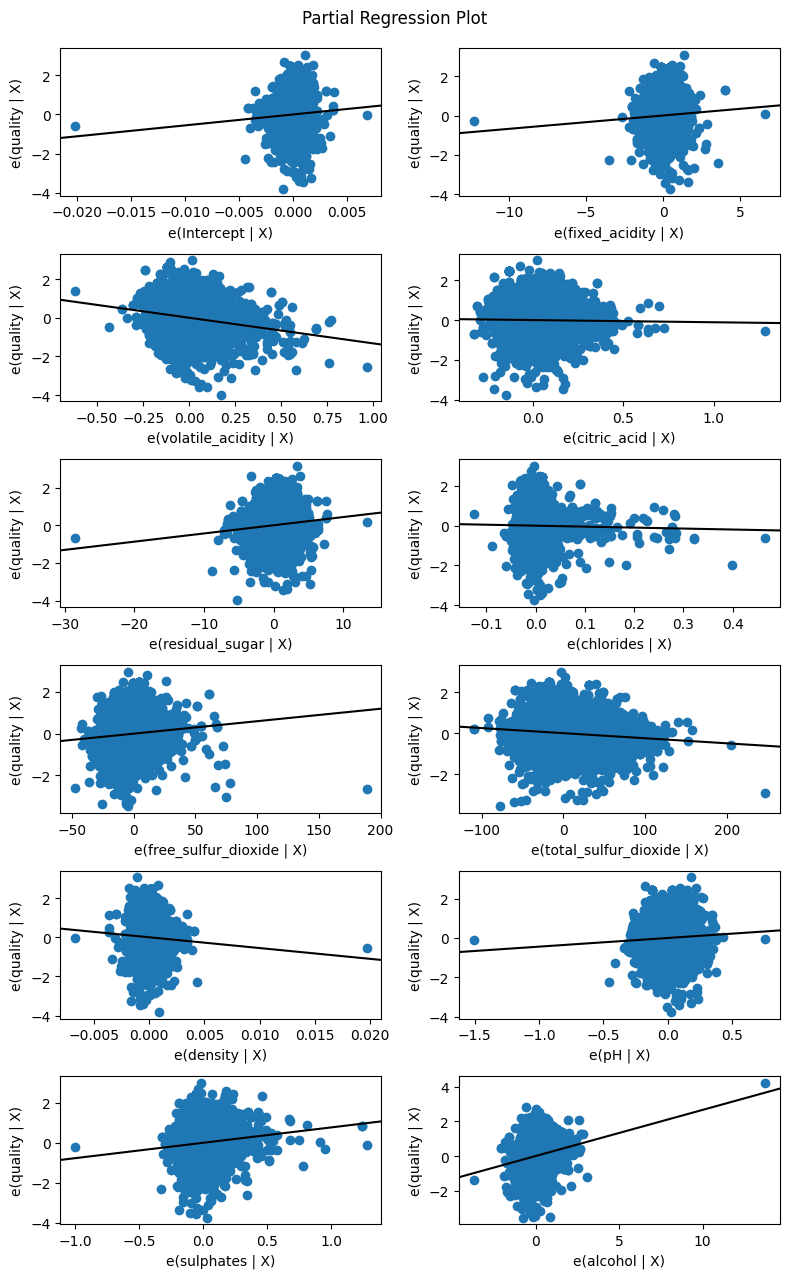

In [21]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

fig = plt.figure(figsize = (8, 13))
sm.graphics.plot_partregress_grid(regression_result, fig = fig)
plt.show()